In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
import PIL.Image as Image

from adjuster.extractors import CannyEdgeDetector

image_path = "DJI_0013_frame_000023.jpg"
img = Image.open(image_path).convert("RGB")

img_tensor = T.ToTensor()(img).cuda()[None]
print(img_tensor.shape)
# img

In [ ]:
edge_extractor = CannyEdgeDetector(device="cuda", **{"sigma": 3.0})
edges = edge_extractor(img_tensor)
edges.shape, edges.device

In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(~(edges.squeeze().cpu().bool()), cmap="gray")
plt.show()

In [ ]:
import pycolmap 

rec = pycolmap.Reconstruction("sparse/0")


In [ ]:
rec.cameras[1].model.name

In [ ]:
for img in rec.images.values():
    break
rec.cameras[img.camera_id].calibration_matrix()

In [ ]:
rec.cameras

In [ ]:
import h5py
import torch
import pycolmap
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

def load_reconstruction(recon_path):
    """Load COLMAP reconstruction."""
    recon = pycolmap.Reconstruction(recon_path)
    cams = recon.cameras
    imgs = recon.images
    id_to_name = {img.image_id: img.name for img in imgs.values()}
    return recon, cams, imgs, id_to_name


def estimate_depth_limits(depth_dir, image_name, default_near=0.1, default_far=5.0):
    """
    Estimate z_near and z_far from per-image depth map (.npy or .exr).
    If not found, return defaults.
    """
    depth_path = Path(depth_dir) / (image_name.split('.')[0] + '.h5')
    if not depth_path.exists():
        print(f"Depth map not found for {depth_path}, using defaults: near={default_near}, far={default_far}")
        return default_near, default_far

    # load h5 file
    depth = h5py.File(depth_path, "r")["depth"][()]
    valid = depth[np.isfinite(depth)]

    if valid.size < 10:
        return default_near, default_far
    
    near = np.percentile(valid, 5)
    far = np.percentile(valid, 95)

    return float(near), float(far)


def compute_frustum_corners(K, width, height, z_near, z_far, R, t, device):
    """Compute 8 frustum corners in world coordinates."""
    corners_px = torch.tensor([
        [0, 0, 1],
        [width, 0, 1],
        [width, height, 1],
        [0, height, 1]
    ], dtype=torch.float32, device=device)

    invK = torch.inverse(K)
    near_pts = (invK @ corners_px.T).T * z_near
    far_pts = (invK @ corners_px.T).T * z_far
    pts_cam = torch.cat([near_pts, far_pts], dim=0)
    # Xw = R^T (Xc - t)
    Xw = (R.T @ (pts_cam.T - t.reshape(3, 1))).T
    return Xw


def aabb_from_points(points):
    """Compute axis-aligned bounding box."""
    return points.min(dim=0).values, points.max(dim=0).values


def aabb_overlap(a_min, a_max, b_min, b_max):
    """Check if AABBs intersect."""
    return torch.all(a_min <= b_max) and torch.all(b_min <= a_max)


def build_view_graph_from_frustums(
    recon_path,
    depth_dir=None,
    z_near_default=0.1,
    z_far_default=5.0,
    max_view_angle_deg=75.0,
    distance_factor=2,
    verbose=True,
):
    """
    Compute view-graph image pairs by frustum intersection, 
    with tighter geometric filtering.
    Args:
        recon_path: path to COLMAP reconstruction folder
        depth_dir: optional path to per-image depth maps (for better near/far estimation)
        device: torch device
        z_near_default: default near plane distance
        z_far_default: default far plane distance
        max_view_angle_deg: maximum allowed view-direction angle difference between cameras. (To reduce pairs: lower the value (e.g., 20°)
        distance_factor: maximum allowed distance between camera centers as a factor of scene size (To reduce pairs: set to 1.0-1.5, to increase pairs: set to 3.0-4.0.)
    """

    recon, cams, imgs, id_to_name = load_reconstruction(recon_path)
    device = "cpu"

    frustums = {}
    aabbs = {}
    centers = {}
    directions = {}

    if verbose is True:
        print("Building camera frustums and computing metadata...")
        bar = tqdm(imgs.values())
    else:
        bar = imgs.values()

    for img in bar:
        cam = cams[img.camera_id]
        K = torch.tensor(cam.calibration_matrix(), dtype=torch.float32, device=device)
        R = torch.tensor(img.cam_from_world.rotation.matrix(), dtype=torch.float32, device=device)
        t = torch.tensor(img.cam_from_world.translation, dtype=torch.float32, device=device)

        if depth_dir:
            z_near, z_far = estimate_depth_limits(depth_dir, img.name)
        else:
            z_near, z_far = z_near_default, z_far_default

        # shrink far plane slightly (avoid wide skinny cones)
        z_far *= 0.9

        corners = compute_frustum_corners(K, cam.width, cam.height, z_near, z_far, R, t, device)
        aabbs[img.image_id] = aabb_from_points(corners)
        frustums[img.image_id] = corners

        # camera center in world = -R^T t
        c_world = -(R.T @ t)
        centers[img.image_id] = c_world
        # camera forward vector in world
        d_world = R.T @ torch.tensor([0., 0., 1.], device=device)
        directions[img.image_id] = d_world / torch.norm(d_world)

    ids = list(imgs.keys())
    pairs = []

    cos_angle_thresh = torch.cos(torch.deg2rad(torch.tensor(max_view_angle_deg, device=device)))

    if verbose:
        print(f"\nChecking {len(ids)} cameras for tight frustum overlaps...")

    for i_idx, i in enumerate(ids):
        a_min, a_max = aabbs[i]
        ci, di = centers[i], directions[i]
        for j in ids[i_idx + 1:]:
            b_min, b_max = aabbs[j]
            cj, dj = centers[j], directions[j]

            # Step 1: AABB intersection (coarse)
            if not aabb_overlap(a_min, a_max, b_min, b_max):
                continue

            # Step 2: view direction consistency
            cos_angle = torch.dot(di, dj)
            if cos_angle < cos_angle_thresh:
                continue  # too divergent (e.g., opposite sides)

            # Step 3: distance filter
            dist = torch.norm(ci - cj)
            scene_scale = torch.norm(a_max - a_min)
            if dist > distance_factor * scene_scale:
                continue

            pairs.append([i, j])

    if verbose:
        print(f"\nFound {len(pairs):,} tight overlapping pairs.")
    return pairs, id_to_name


def save_pairs_to_file(pairs, id_to_name, output_file="pairs.txt"):
    """Save view-graph pairs to text file (COLMAP-style)."""
    out_pairs = []
    for i, j in pairs:
        sorted_ij = sorted([id_to_name[i], id_to_name[j]])
        out_pairs.append([sorted_ij[0], sorted_ij[1]])
    
    if output_file is None:
        with open("pairs_debug.txt", "w") as f:
            for i, j in out_pairs:
                f.write(f"{i} {j}\n")

    # sort pairs by first image name and then second image name
    out_pairs = sorted(out_pairs, key=lambda x: (x[0], x[1]))

    return out_pairs


In [ ]:
# Define paths
recon_path = "/home/mattia/Desktop/datasets/mydataset/data/udine_castello_fagagna/colmap/sparse/0"
depth_dir = "/home/mattia/Desktop/datasets/mydataset/data/udine_castello_fagagna/depth"

# Run view-graph building
pairs, id_to_name = build_view_graph_from_frustums(
    recon_path,
    depth_dir=None, # not changing much, so we skip depth maps for speed
    verbose=True,
)

# Optionally save
pairs = save_pairs_to_file(pairs, id_to_name, None) #"sparse/pairs.txt")

pairs[:5]

In [ ]:
# # load pairs
# with open("sparse/pairs.txt", "r") as f:
#     pairs = [line.strip().split() for line in f.readlines()]    

for n in [15, 30, 50]:
    # load viewgraph_15.txt
    with open(f"/home/mattia/Desktop/datasets/mydataset/data/udine_castello_fagagna/colmap/viewgraph_{n}.txt", "r") as f:
        viewgraph = [line.strip().split()[:2] for line in f.readlines()]

    # Convert to tuple-based set once
    viewgraph_set = {tuple(p) for p in viewgraph}
    overlap_pairs = {(a, b) for (a, b) in pairs if (a, b) in viewgraph_set or (b, a) in viewgraph_set}
    print(f"Viewgraph pairs ({n}): {len(viewgraph):,}, Found pairs: {len(pairs):,}, Correct pairs found: {len(overlap_pairs):,} ({len(overlap_pairs)/len(viewgraph)*100:.2f}%)")


In [ ]:
import os

res = {}
for scene in tqdm(sorted(os.listdir("/home/mattia/Desktop/datasets/mydataset/data"))):

    # Define paths
    recon_path = f"/home/mattia/Desktop/datasets/mydataset/data/{scene}/colmap/sparse/0"

    # Run view-graph building
    pairs, id_to_name = build_view_graph_from_frustums(
        recon_path,
        depth_dir=None,
        verbose=False,
    )

    pairs = save_pairs_to_file(pairs, id_to_name, None)  #"sparse/pairs.txt")

    # load viewgraph_30.txt
    with open(f"/home/mattia/Desktop/datasets/mydataset/data/{scene}/colmap/viewgraph_30.txt", "r") as f:
        viewgraph = [line.strip().split()[:2] for line in f.readlines()]

    # Convert to tuple-based set once
    viewgraph_set = {tuple(p) for p in viewgraph}
    overlap_pairs = {(a, b) for (a, b) in pairs if (a, b) in viewgraph_set or (b, a) in viewgraph_set}
    # print(f"Viewgraph pairs ({n}): {len(viewgraph):,}, Found pairs: {len(pairs):,}, Correct pairs found: {len(overlap_pairs):,} ({len(overlap_pairs)/len(viewgraph)*100:.2f}%)")

    res[scene] = {
        "viewgraph_pairs": len(viewgraph),
        "found_pairs": len(pairs),
        "overlap_pairs": len(overlap_pairs),
    }

In [ ]:
import pandas as pd

df = pd.DataFrame.from_dict(res, orient="index")
df["correctness"] = df["overlap_pairs"] / df["viewgraph_pairs"]
df

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
plt.bar(df.index, df["correctness"])
# plot median and avg lines
plt.axhline(y=df["correctness"].mean(), color='r', linestyle='--', label='Average')
plt.axhline(y=df["correctness"].median(), color='g', linestyle='--', label='Median')
plt.legend()
plt.xticks(rotation=90)
plt.ylabel("Correctness")
plt.show()

In [265]:
from adjuster.adjuster import Adjuster

adjuster = Adjuster()

CannyEdgeDetector initialized with low_threshold=0.15, high_threshold=0.25, hysteresis=True, kernel_size=9, sigma=7.0, device=cuda


In [266]:
out = adjuster(
    "/home/mattia/Desktop/Repos/wrapper_factory/benchmarks_3D/eth3d/pipes/images_by_k",
    depths_path = "/home/mattia/Desktop/Repos/vggt/wrapper_output/sparse/depth_maps",
    reconstruction = "/home/mattia/Desktop/Repos/vggt/wrapper_output/sparse"
)

Found 14 images in /home/mattia/Desktop/Repos/wrapper_factory/benchmarks_3D/eth3d/pipes/images_by_k


Loading depth maps: 100%|██████████| 14/14 [00:00<00:00, 975.86it/s]

Timings:
----------------------------------------
viewgraph                           0.03 s      2.9%
load_images                         0.87 s     77.9%
extract_edges                       0.19 s     17.1%
load_poses_and_intrinsics           0.00 s      0.1%
load_depth_maps                     0.02 s      2.0%
----------------------------------------
total                               1.12 s


44
0/DSC_0636.JPG 0/DSC_0645.JPG


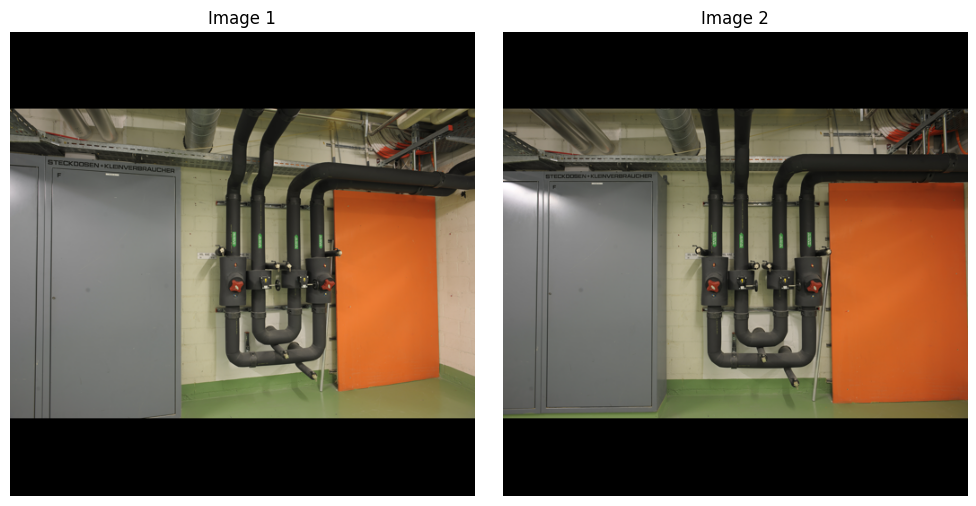

In [267]:
from mylib.plot import plot_imgs
images, viewgraph, intrinsics = out
print(len(viewgraph ))
i,j = viewgraph[20]
print(i, j)

i, j = "0/DSC_0634.JPG 0/DSC_0635.JPG".split()

plot_imgs([images[i]['image'].permute(1,2,0).cpu(), images[j]['image'].permute(1,2,0).cpu()])

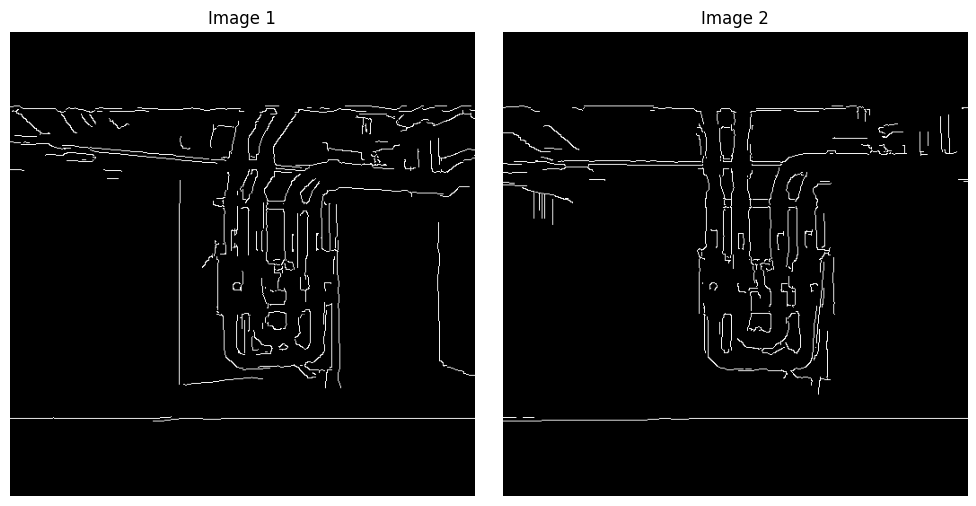

In [268]:
plot_imgs([images[i]['edges'], images[j]['edges']], cmap="gray")

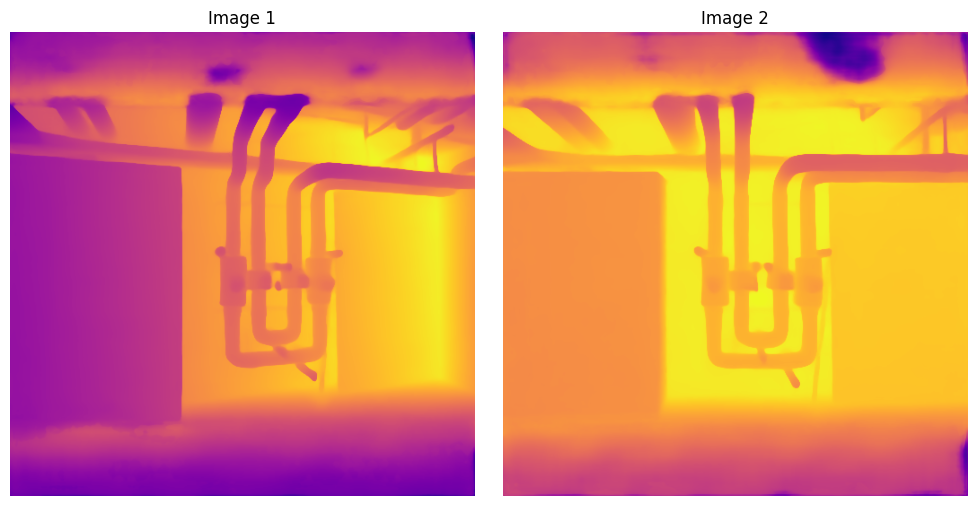

In [269]:
plot_imgs([images[i]['depth'], images[j]['depth']], cmap="plasma")

In [270]:
# visual test: can I reproject the points correctly?
import torch
import h5py

from mylib.from_eslibutils import reproject_2D_2D
from mylib.conversions import to_torch


def create_grid(image, permute=False, sampling_factor=10, border=30):
    """
    Function to create a grid of the same size as the image.
    Args:
        image: image of shape BxCxHxW or CxHxW
        permute: if True, the grid is permuted
    Returns:
        grid: grid of the same size as the image HxWx2
    """
    image = image[None] if image.dim() == 3 else image
    H, W = image.shape[-2:]

    grid_y, grid_x = torch.meshgrid(
        torch.arange(border, H-border, sampling_factor), 
        torch.arange(border, W-border, sampling_factor), 
        indexing='ij') 
    grid = torch.stack((grid_x, grid_y), dim=-1).view(-1,2).float()  

    grid = grid[torch.randperm(grid.shape[0])] if permute else grid
    
    return grid


def dist(p0, p1):
    '''
    Euclidean distance between two points
    Args:
        p0: point 0 (N,2)
        p1: point 1 (N,2)
    Returns:
        dist: distance between the points (N,)
    '''
    return torch.sqrt(((p0 - p1)**2).sum(dim=-1))


def compute_121_reprojection(data, img0, img1, verbose=True, reprojection_error=3.0, border=30, sampling_factor=10):
        # create a grid of points in img 0 
        kpts0 = create_grid(img0, sampling_factor=sampling_factor, border=border)[None] 
        # starting from depth valid locations, in nan is invalid in any case
        # kpts0 = torch.nonzero(~torch.isnan(data['depth0'][0]))[None].float() # why not working?
        tot = kpts0.numel()

        # project the points to img1
        kpts1 = reproject_2D_2D(xy0=kpts0, 
                              depthmap0=data['depth0'],
                              P0=data['P0'], P1=data['P1'],
                              K0=data['K0'], K1=data['K1'],
                              img1_shape=(img1.shape[-2], img1.shape[-1])
                              )
        
        # back project the points to img0
        kpts0_back = reproject_2D_2D(xy0=kpts1,
                                depthmap0=data['depth1'],
                                P0=data['P1'], P1=data['P0'],
                                K0=data['K1'], K1=data['K0'],
                                img1_shape=(img0.shape[-2], img0.shape[-1])
                                )
        
        if verbose:
            print(kpts0.shape, kpts1.shape, kpts0_back.shape, 'projected')

        # detect nans and remove if any, no need for kpts0
        nan_mask = torch.logical_and(torch.isnan(kpts1).any(dim=-1), torch.isnan(kpts0_back)[0].any(dim=-1))
        kpts0 = kpts0[~nan_mask]
        kpts1 = kpts1[~nan_mask]
        kpts0_back = kpts0_back[~nan_mask]
       
        if verbose:
            print(kpts0.shape, kpts1.shape, 'removed nan')

        # check if back projections is close enough to the original points
        mask = dist(kpts0, kpts0_back) < reprojection_error
        kpts0 = kpts0[mask]
        kpts1 = kpts1[mask]

        # check projection to be within border margin for kpt1
        mask_x = torch.logical_and(kpts1[:,0] > border, kpts1[:,0] < img1.shape[-1]-border)
        mask_y = torch.logical_and(kpts1[:,1] > border, kpts1[:,1] < img1.shape[-2]-border)
        mask = torch.logical_and(mask_x, mask_y)
        kpts0 = kpts0[mask]
        kpts1 = kpts1[mask]

        return kpts0, kpts1, tot

In [271]:
x1,y1,x2,y2,h,w = [int(x) for x in images[i]['coords']]
img1 = images[i]['image'][:, y1:y2, x1:x2]
img2 = images[j]['image'][:, y1:y2, x1:x2]
edge1 = images[i]['edges'][y1:y2, x1:x2]
edge2 = images[j]['edges'][y1:y2, x1:x2]
Z1 = images[i]['depth'][y1:y2, x1:x2][None]
Z2 = images[j]['depth'][y1:y2, x1:x2][None]

In [272]:
data = {'P0': images[i]['P'][None], 'P1': images[j]['P'][None],
     'K0': intrinsics[images[i]['cam_id']][None],  'K1': intrinsics[images[j]['cam_id']][None],
     'depth0': Z1, 'depth1': Z2}

kpts1, kpts2, tot = compute_121_reprojection(
    data,
    img1, img2,
    verbose=False, reprojection_error=3.0, border=5, sampling_factor=1)

print(f"Consistent points: {len(kpts1):,}, {len(kpts2):,} out of {tot:,} ({100*len(kpts1)/tot:.4f}%)")

Consistent points: 129,854, 129,854 out of 340,360 (38.1520%)


In [273]:
edge1_kpts = edge1.nonzero().flip(dims=(0,1))
edge2_kpts = edge2.nonzero().flip(dims=(0,1))

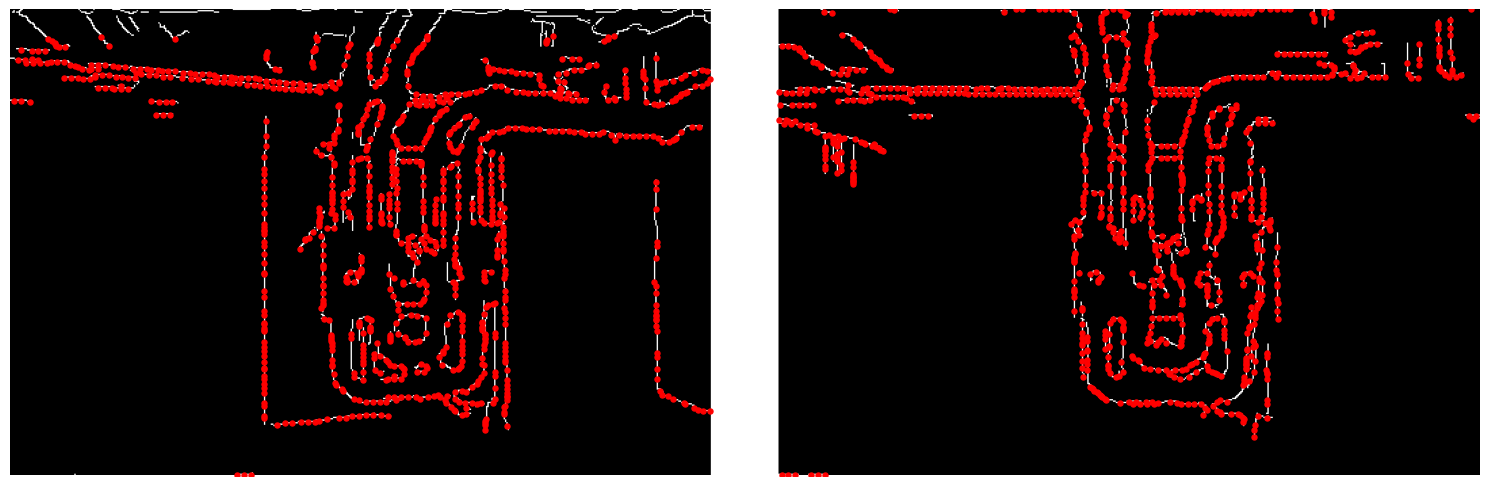

In [274]:
from mylib.plot import plot_imgs_and_kpts


plot_imgs_and_kpts(
    edge1[..., None].repeat(1,1,3).cpu()*255//1,
    edge2[..., None].repeat(1,1,3).cpu()*255//1,
    edge1_kpts, edge2_kpts,
    sample_points=1_000, index=False, matches=False,
    # sample_points=10_000, index=True, matches=True,
) 